In [1]:
!pip install -q torch transformers matplotlib

In [2]:
import torch
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

In [5]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

model.eval()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [9]:
text = ["Large Language Models are computer programs trained on huge amounts of text."]

inputs = tokenizer(text,return_tensors="pt",padding=True,truncation=True)

print(inputs)

{'input_ids': tensor([[ 101, 2312, 2653, 4275, 2024, 3274, 3454, 4738, 2006, 4121, 8310, 1997,
         3793, 1012,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [10]:
batch_sizes = [1, 2, 4, 8]

total_times = []
time_per_sample = []

for batch_size in batch_sizes:

    batch = {
        key: value[:batch_size]
        for key, value in inputs.items()
    }

    with torch.no_grad():
        model(**batch)

    start_time = time.perf_counter()

    with torch.no_grad():
        model(**batch)
    end_time = time.perf_counter()

    total_time = end_time - start_time
    per_sample = total_time / batch_size

    total_times.append(total_time)
    time_per_sample.append(per_sample)

    print(f"Batch Size: {batch_size}")
    print(f"Total Time: {total_time:.4f} seconds")
    print(f"Time per Sample: {per_sample:.4f} seconds")
    print("-" * 35)

Batch Size: 1
Total Time: 0.2834 seconds
Time per Sample: 0.2834 seconds
-----------------------------------
Batch Size: 2
Total Time: 0.1627 seconds
Time per Sample: 0.0813 seconds
-----------------------------------
Batch Size: 4
Total Time: 0.1144 seconds
Time per Sample: 0.0286 seconds
-----------------------------------
Batch Size: 8
Total Time: 0.1253 seconds
Time per Sample: 0.0157 seconds
-----------------------------------


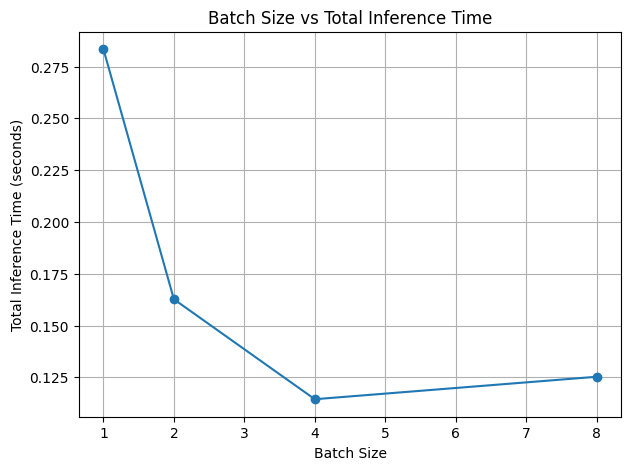

In [11]:
plt.figure(figsize=(7, 5))

plt.plot(batch_sizes, total_times, marker="o")

plt.xlabel("Batch Size")
plt.ylabel("Total Inference Time (seconds)")
plt.title("Batch Size vs Total Inference Time")

plt.grid(True)
plt.show()

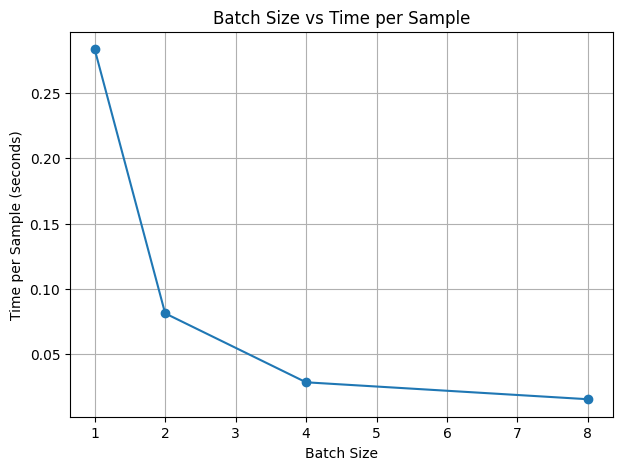

In [12]:
plt.figure(figsize=(7, 5))

plt.plot(batch_sizes, time_per_sample, marker="o")

plt.xlabel("Batch Size")
plt.ylabel("Time per Sample (seconds)")
plt.title("Batch Size vs Time per Sample")

plt.grid(True)
plt.show()